<a href="https://colab.research.google.com/github/Keistkmiya/UTS-MachineLearning/blob/main/UTS_Bag1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyek End-to-End Machine Learning**

## **Setup dan Instalasi Library**

In [ ]:
!pip install mlflow optuna -q

## **Import Library dan Load Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import optuna

%matplotlib inline
sns.set_theme(style="whitegrid")

In [ ]:
url = "https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


### Inspeksi Data

In [ ]:
df.info()

print("\nJumlah Missing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280833 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280833 non-null  object 
 1   County                                             280821 non-null  object 
 2   City                                               280821 non-null  object 
 3   State                                              280833 non-null  object 
 4   Postal Code                                        280821 non-null  float64
 5   Model Year                                         280833 non-null  int64  
 6   Make                                               280833 non-null  object 
 7   Model                                              280833 non-null  object 
 8   Electric Vehicle Type                              280833 non-null  object

## **Pembersihan Data dan EDA**

In [ ]:
cols_to_drop = ['VIN (1-10)', 'DOL Vehicle ID', 'Vehicle Location', '2020 Census Tract', 'Postal Code']
df_clean = df.drop(columns=cols_to_drop)
df_clean = df_clean.dropna()

print(f"Ukuran data setelah dibersihkan: {df_clean.shape}")
df_clean.head()

Ukuran data setelah dibersihkan: (280118, 11)


,County,City,State,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,King,Kirkland,WA,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
1,Kitsap,Bainbridge Island,WA,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,PUGET SOUND ENERGY INC
2,King,Seattle,WA,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
3,Thurston,Yelm,WA,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,PUGET SOUND ENERGY INC
4,King,Kent,WA,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)


### Visualisasi Distribusi Target

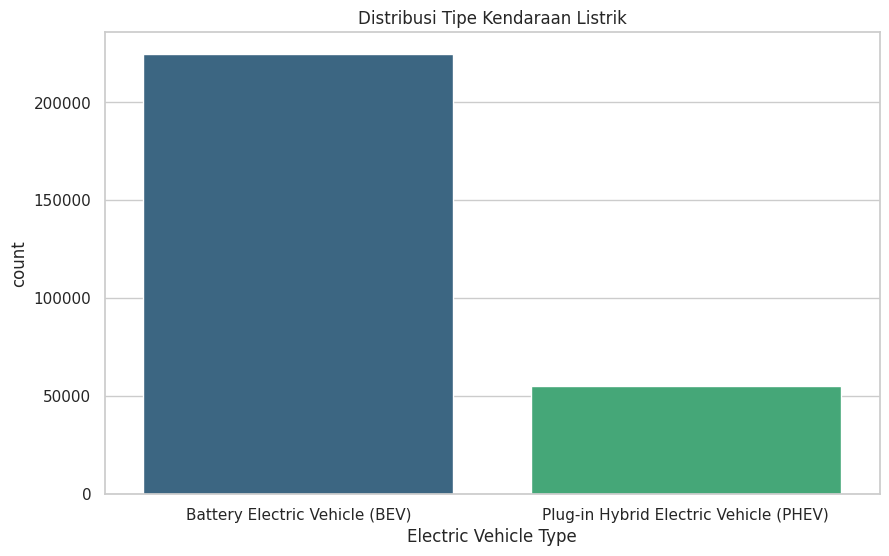

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Electric Vehicle Type', hue='Electric Vehicle Type', palette='viridis', legend=False)
plt.title('Distribusi Tipe Kendaraan Listrik')
plt.show()

## **Feature Engineering**

### Encoding Variabel Kategorikal

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop(columns=['Electric Vehicle Type'])
y = df_encoded['Electric Vehicle Type']

print(X.dtypes)

County                                                 int64
City                                                   int64
State                                                  int64
Model Year                                             int64
Make                                                   int64
Model                                                  int64
Clean Alternative Fuel Vehicle (CAFV) Eligibility      int64
Electric Range                                       float64
Legislative District                                 float64
Electric Utility                                       int64
dtype: object


### Pemisahan Feature dan Target

In [ ]:
X = df_encoded.drop(columns=['Electric Vehicle Type'])
y = df_encoded['Electric Vehicle Type']

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (280118, 10)
Ukuran y: (280118,)


## **Pembagian Data (Train-Test Split)**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Training: {X_train.shape}")
print(f"Data Testing: {X_test.shape}")

Data Training: (224094, 10)
Data Testing: (56024, 10)


## **Training Model Dasar & Tracking MLflo**w

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

mlflow.set_experiment("Eksperimen_EV_Type")

with mlflow.start_run(run_name="Baseline_RandomForest"):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("accuracy", acc)

    print(f"Model Baseline Accuracy: {acc:.4f}")

Model Baseline Accuracy: 1.0000


## **Menangani Data Leakage**

### Menghapus Fitur yang Berpotensi Leakage

In [ ]:
X_refined = X.drop(columns=['Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range'])
X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(X_refined, y, test_size=0.2, random_state=42)

print(f"Fitur sekarang: {list(X_refined.columns)}")

Fitur sekarang: ['County', 'City', 'State', 'Model Year', 'Make', 'Model', 'Legislative District', 'Electric Utility']


In [ ]:
with mlflow.start_run(run_name="Refined_RandomForest"):
    model_ref = RandomForestClassifier(n_estimators=100, random_state=42)
    model_ref.fit(X_train_ref, y_train_ref)

    y_pred_ref = model_ref.predict(X_test_ref)
    acc_ref = accuracy_score(y_test_ref, y_pred_ref)

    mlflow.log_metric("accuracy", acc_ref)
    print(f"Model Refined Accuracy: {acc_ref:.4f}")

Model Refined Accuracy: 0.9915


## **Hyperparameter Tuning dengan Optuna**

### Definisi Objective Function

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    model.fit(X_train_ref, y_train_ref)

    y_pred = model.predict(X_test_ref)
    accuracy = accuracy_score(y_test_ref, y_pred)

    return accuracy

### Menjalankan Optuna Study

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"Akurasi terbaik: {study.best_value:.4f}")
print(f"Parameter terbaik: {study.best_params}")

[I 2026-05-04 09:48:38,951] A new study created in memory with name: no-name-1c5f3b53-7937-4e12-a34f-3021d7927e87
[I 2026-05-04 09:49:05,794] Trial 0 finished with value: 0.982632443238612 and parameters: {'n_estimators': 173, 'max_depth': 11, 'min_samples_split': 3}. Best is trial 0 with value: 0.982632443238612.
[I 2026-05-04 09:49:26,741] Trial 1 finished with value: 0.9924139654433815 and parameters: {'n_estimators': 124, 'max_depth': 19, 'min_samples_split': 7}. Best is trial 1 with value: 0.9924139654433815.
[I 2026-05-04 09:49:32,803] Trial 2 finished with value: 0.929851492217621 and parameters: {'n_estimators': 59, 'max_depth': 5, 'min_samples_split': 4}. Best is trial 1 with value: 0.9924139654433815.
[I 2026-05-04 09:49:48,695] Trial 3 finished with value: 0.9586070255604741 and parameters: {'n_estimators': 116, 'max_depth': 8, 'min_samples_split': 10}. Best is trial 1 with value: 0.9924139654433815.
[I 2026-05-04 09:49:59,254] Trial 4 finished with value: 0.9471476510067114

Akurasi terbaik: 0.9924
Parameter terbaik: {'n_estimators': 124, 'max_depth': 19, 'min_samples_split': 7}


### Menjalankan Optuna Study

## **Training Model Final & Evaluasi Detail**

In [ ]:
best_params = study.best_params

with mlflow.start_run(run_name="Final_Model_Optimized"):
    final_model = RandomForestClassifier(**best_params, random_state=42)

    final_model.fit(X_train_ref, y_train_ref)

    y_pred_final = final_model.predict(X_test_ref)

    mlflow.log_params(best_params)

    final_acc = accuracy_score(y_test_ref, y_pred_final)
    mlflow.log_metric("final_accuracy", final_acc)

    print(f"Akurasi Model Final: {final_acc:.4f}")

Akurasi Model Final: 0.9924


### Classification Report

In [ ]:
print(classification_report(y_test_ref, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     44714
           1       0.99      0.97      0.98     11310

    accuracy                           0.99     56024
   macro avg       0.99      0.99      0.99     56024
weighted avg       0.99      0.99      0.99     56024



##**Dashboard MLflow**

In [ ]:
!pip install pyngrok -q
from pyngrok import ngrok
import os
import time

# 1. Matikan semua proses lama agar tidak tabrakan
!pkill mlflow
!pkill ngrok

# 2. MASUKKAN TOKEN KAMU DI SINI (Wajib)
# Ambil di: https://dashboard.ngrok.com/get-started/your-authtoken
MY_NGROK_TOKEN = "MASUKKAN_TOKEN_DI_SINI"
ngrok.set_auth_token(MY_NGROK_TOKEN)

# 3. Jalankan MLflow UI di background
os.system("mlflow ui --port 5000 --host 0.0.0.0 &")
time.sleep(3) # Tunggu server siap

# 4. Buat tunnel dengan jurus 'host_header rewrite'
# Ini yang akan menghilangkan error "Invalid Host header"
public_url = ngrok.connect(5000, options={"host_header": "rewrite"})

print(f"🚀 Dashboard MLflow siap! Klik di sini: {public_url}")

ERROR:pyngrok.process.ngrok:t=2026-05-04T09:57:12+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: MASUKKAN_TOKEN_DI_SINI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-04T09:57:12+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: MASUKKAN_TOKEN_DI_SINI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-04T09:57:12+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: The authtoken you specified does not look like a proper ngrok a

PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: MASUKKAN_TOKEN_DI_SINI\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.